# Predictive Maintenance — ML pipeline

**Тема:** Machine Learning Methods and Models for Predicting the Technical Condition of Industrial Equipment.

Цель notebook — показать полный воспроизводимый эксперимент: данные → EDA → отсутствие leakage → train/validation/test → baseline → несколько ML-моделей → выбор threshold → метрики → error analysis → SHAP → сохранение модели.

> **Важно о данных.** В комплекте находится `data/ai4i2020_offline_replica.csv` — локальная воспроизводимая **AI4I-style replica**, созданная по публично описанным правилам UCI AI4I 2020. Это не байт-в-байт официальный CSV. Причина — проект должен запускаться без интернета. При финальной сдаче можно заменить файл на официальный AI4I 2020 CSV; pipeline и названия основных колонок сохранены совместимыми.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             precision_recall_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import shap

ROOT = Path.cwd()
if not (ROOT / "src_pipeline.py").exists():
    ROOT = Path("/mnt/data/predictive_maintenance_project")
sys.path.insert(0, str(ROOT))

from src_pipeline import (BASE_FEATURES, FAILURE_MODE_COLUMNS, TARGET, add_engineered_features,
                          build_preprocessor, choose_f2_threshold, classification_metrics)
SEED = 42
print("Project root:", ROOT.name)

Project root: Predictive_Maintenance_Project_Final


## 1. Данные

Официальный UCI AI4I 2020 содержит 10 000 наблюдений и 6 основных входных признаков. Для локального воспроизводимого запуска используется replica с той же структурой входов и опубликованными механизмами отказов.

**В модель не передаются:** `UDI`, `Product ID`, а также `TWF/HDF/PWF/OSF/RNF`. Последние колонки напрямую описывают причины отказа и дали бы **target leakage**.

In [2]:
df = pd.read_csv(ROOT / "data" / "ai4i2020_offline_replica.csv")
print("shape =", df.shape)
print("missing values =", int(df.isna().sum().sum()))
display(df.head())

summary = pd.DataFrame({
    "rows": [len(df)],
    "failures": [int(df[TARGET].sum())],
    "failure_rate": [df[TARGET].mean()],
})
display(summary)

shape = (10000, 14)
missing values = 0


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M10000,M,302.4,314.4,1925,21.2,0,0,0,0,0,0,0
1,2,L10001,L,302.4,314.6,1366,51.3,3,0,0,0,0,0,0
2,3,H10002,H,302.4,314.6,1332,51.8,5,0,0,0,0,0,0
3,4,M10003,M,302.3,314.6,1716,35.3,10,0,0,0,0,0,0
4,5,L10004,L,302.2,314.5,1450,45.2,13,0,0,0,0,0,0


,rows,failures,failure_rate
0,10000,373,0.0373


### Optional: заменить replica на официальный UCI dataset

При наличии интернета можно скачать официальный dataset через `ucimlrepo` (`id=601`) или с UCI Repository и сохранить его как отдельный CSV. Не смешивайте результаты replica и official dataset в одной таблице без явной маркировки.

In [3]:
USE_OFFICIAL_UCI = False
if USE_OFFICIAL_UCI:
    try:
        from ucimlrepo import fetch_ucirepo
        official = fetch_ucirepo(id=601)
        print(official.metadata)
    except Exception as exc:
        print("Official fetch unavailable:", exc)

## 2. EDA и class imbalance

Класс отказа редкий. Поэтому высокая **accuracy** сама по себе ничего не гарантирует: модель, которая всегда предсказывает `Normal`, уже получает высокую accuracy, но recall отказов равен нулю.

Machine failure
0    9627
1     373
Name: count, dtype: int64
Failure rate: 3.73%


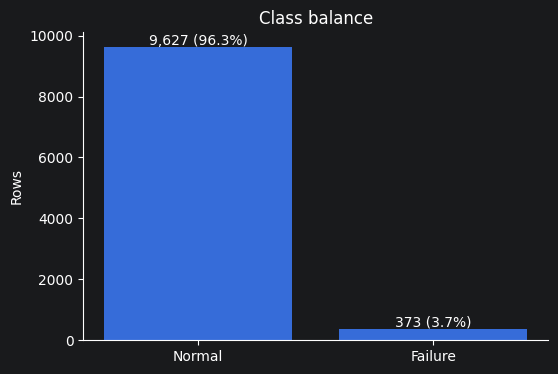

In [4]:
class_counts = df[TARGET].value_counts().sort_index()
print(class_counts)
print("Failure rate:", f"{df[TARGET].mean():.2%}")

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(["Normal", "Failure"], class_counts.values)
ax.set_title("Class balance")
ax.set_ylabel("Rows")
for i,v in enumerate(class_counts.values):
    ax.text(i, v+80, f"{v:,} ({v/len(df):.1%})", ha='center')
ax.spines[['top','right']].set_visible(False)
plt.show()

In [5]:
display(df[BASE_FEATURES + [TARGET]].describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Type,10000,3,L,5015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air temperature [K],10000.0,NaN,NaN,NaN,299.9999,2.000611,296.5,298.0,300.9,301.8,303.1
Process temperature [K],10000.0,NaN,NaN,NaN,310.00004,2.748485,305.0,307.4,310.7,312.4,315.7
Rotational speed [rpm],10000.0,NaN,NaN,NaN,1537.2588,178.846358,1100.0,1414.0,1541.0,1660.0,2264.0
Torque [Nm],10000.0,NaN,NaN,NaN,40.14009,10.018977,3.0,33.3,40.0,46.9,80.0
Tool wear [min],10000.0,NaN,NaN,NaN,109.6345,64.913677,0.0,54.0,109.0,165.0,239.0
Machine failure,10000.0,NaN,NaN,NaN,0.0373,0.189505,0.0,0.0,0.0,0.0,1.0


## 3. Feature engineering

Добавляем три физических/инженерных признака только из доступных входов:

- `Temperature gap = process temperature − air temperature`
- `Mechanical power = torque × angular speed`
- `Wear × torque`

Это не leakage: все три величины вычисляются из входов, доступных во время inference.

In [6]:
df_eng = add_engineered_features(df[BASE_FEATURES])
display(df_eng.head())

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature gap [K],Mechanical power [W],Wear × torque
0,M,302.4,314.4,1925,21.2,0,12.0,4273.613206,0.0
1,L,302.4,314.6,1366,51.3,3,12.2,7338.320616,153.9
2,H,302.4,314.6,1332,51.8,5,12.2,7225.411776,259.0
3,M,302.3,314.6,1716,35.3,10,12.3,6343.378222,353.0
4,L,302.2,314.5,1450,45.2,13,12.3,6863.332751,587.6


## 4. Train / validation / test

Разбиение: **70 / 15 / 15**, stratified по target. Test set блокируется до финальной оценки. Validation используется для выбора decision threshold. Random seed фиксирован.

In [7]:
X = df[BASE_FEATURES]
y = df[TARGET]
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

X_train_e = add_engineered_features(X_train)
X_val_e = add_engineered_features(X_val)
X_test_e = add_engineered_features(X_test)

splits = pd.DataFrame({
    'split':['train','validation','test'],
    'rows':[len(X_train),len(X_val),len(X_test)],
    'failures':[int(y_train.sum()),int(y_val.sum()),int(y_test.sum())],
    'failure_rate':[y_train.mean(),y_val.mean(),y_test.mean()]
})
display(splits)

,split,rows,failures,failure_rate
0,train,7000,261,0.037286
1,validation,1500,56,0.037333
2,test,1500,56,0.037333


## 5. Модели

Сравниваются:

1. **Dummy baseline** — показывает ловушку accuracy.
2. **Logistic Regression** — простой интерпретируемый linear baseline.
3. **Random Forest** — нелинейный ensemble.
4. **XGBoost** — gradient boosting для табличных данных.

Для Logistic/RF/XGBoost используется imbalance handling. Для каждого реального ML-моделя threshold выбирается **только на validation** по F2-score, где recall важнее precision.

In [8]:
positive = int(y_train.sum())
negative = len(y_train) - positive
scale_pos_weight = negative / positive

models = {
    'Dummy baseline': Pipeline([
        ('preprocess', build_preprocessor(False)),
        ('model', DummyClassifier(strategy='prior'))
    ]),
    'Logistic Regression': Pipeline([
        ('preprocess', build_preprocessor(True)),
        ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED))
    ]),
    'Random Forest': Pipeline([
        ('preprocess', build_preprocessor(True)),
        ('model', RandomForestClassifier(n_estimators=500, class_weight='balanced_subsample',
                                         n_jobs=-1, random_state=SEED))
    ]),
    'XGBoost': Pipeline([
        ('preprocess', build_preprocessor(True)),
        ('model', XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
                                min_child_weight=2, subsample=0.9, colsample_bytree=0.9,
                                reg_lambda=2.0, scale_pos_weight=scale_pos_weight,
                                objective='binary:logistic', eval_metric='logloss',
                                n_jobs=-1, random_state=SEED))
    ])
}
print('scale_pos_weight =', round(scale_pos_weight, 2))

scale_pos_weight = 25.82


In [9]:
rows=[]
fitted={}
thresholds={}
test_scores={}

for name, model in models.items():
    engineered = name != 'Dummy baseline'
    tr = X_train_e if engineered else X_train
    va = X_val_e if engineered else X_val
    te = X_test_e if engineered else X_test
    model.fit(tr, y_train)
    val_score = model.predict_proba(va)[:,1]
    threshold = 0.5 if name == 'Dummy baseline' else choose_f2_threshold(y_val, val_score)
    test_score = model.predict_proba(te)[:,1]
    rows.append(classification_metrics(name, y_test, test_score, threshold))
    fitted[name] = model
    thresholds[name] = threshold
    test_scores[name] = test_score

metrics = pd.DataFrame(rows)
display(metrics[['model','threshold','accuracy','precision','recall','f1','f2','roc_auc','pr_auc','fp','fn','tp']].round(3))

,model,threshold,accuracy,precision,recall,f1,f2,roc_auc,pr_auc,fp,fn,tp
0,Dummy baseline,0.50,0.963,0.000,0.000,0.000,0.000,0.500,0.037,0,56,0
1,Logistic Regression,0.77,0.933,0.284,0.518,0.367,0.445,0.902,0.362,73,27,29
2,Random Forest,0.22,0.989,0.885,0.821,0.852,0.833,0.975,0.883,6,10,46
3,XGBoost,0.73,0.989,0.882,0.804,0.841,0.818,0.987,0.903,6,11,45


### Что видно из baseline

Dummy показывает высокую accuracy, но **0 обнаруженных отказов**. Это главный аргумент, почему для imbalanced classification мы смотрим на recall, F1/F2 и особенно PR-AUC.

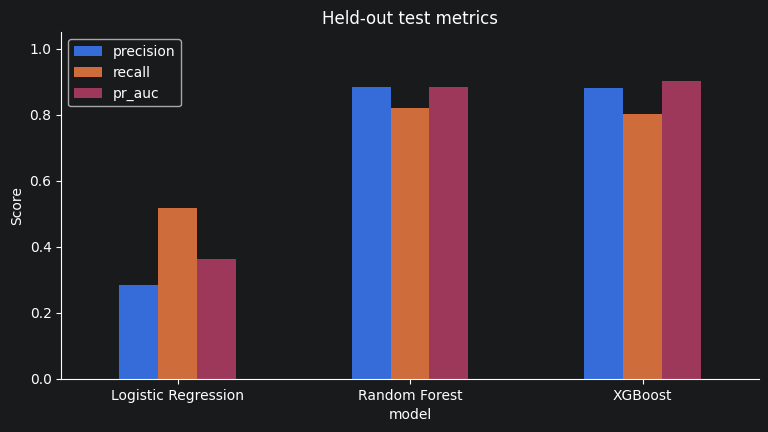

In [10]:
plot_df = metrics[metrics.model != 'Dummy baseline'].set_index('model')[['precision','recall','pr_auc']]
ax = plot_df.plot(kind='bar', figsize=(9,4.5), rot=0)
ax.set_ylim(0,1.05); ax.set_ylabel('Score'); ax.set_title('Held-out test metrics')
ax.spines[['top','right']].set_visible(False)
plt.show()

## 6. Precision–Recall curve и финальная модель

По ranking quality XGBoost показывает самый высокий PR-AUC. Поэтому для prototype используется XGBoost. Decision threshold не равен автоматически 0.5: он выбран на validation по F2.

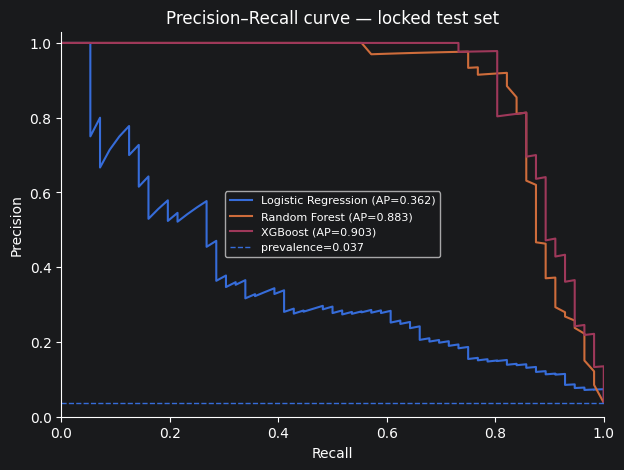

In [11]:
fig, ax = plt.subplots(figsize=(7,5))
for name in ['Logistic Regression','Random Forest','XGBoost']:
    p, r, _ = precision_recall_curve(y_test, test_scores[name])
    ap = average_precision_score(y_test, test_scores[name])
    ax.plot(r, p, label=f'{name} (AP={ap:.3f})')
ax.axhline(y_test.mean(), linestyle='--', linewidth=1, label=f'prevalence={y_test.mean():.3f}')
ax.set(xlabel='Recall', ylabel='Precision', title='Precision–Recall curve — locked test set', xlim=(0,1), ylim=(0,1.03))
ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)
plt.show()

threshold = 0.73
confusion matrix:
 [[1438    6]
 [  11   45]]


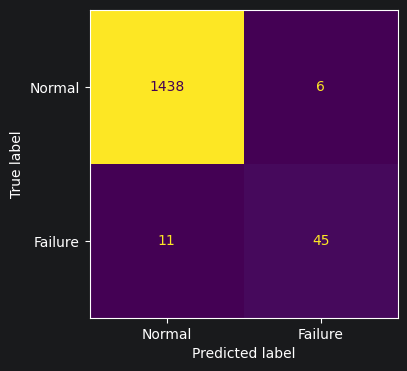

In [12]:
final_name = 'XGBoost'
final_model = fitted[final_name]
final_threshold = thresholds[final_name]
final_score = test_scores[final_name]
final_pred = final_score >= final_threshold
print('threshold =', final_threshold)
print('confusion matrix:\n', confusion_matrix(y_test, final_pred))
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(y_test, final_pred, display_labels=['Normal','Failure'],
                                        values_format='d', colorbar=False, ax=ax)
plt.show()

## 7. Ablation: помогают ли engineered features?

Сравниваем один и тот же XGBoost с 6 исходными признаками и с 3 добавленными инженерными признаками. Это эксперимент на влияние feature engineering, а не просто сравнение разных алгоритмов.

In [13]:
ablation=[]
for label, engineered in [('Raw 6 features', False), ('+ 3 engineered features', True)]:
    model = Pipeline([
        ('preprocess', build_preprocessor(engineered)),
        ('model', XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, min_child_weight=2,
                                subsample=0.9, colsample_bytree=0.9, reg_lambda=2.0,
                                objective='binary:logistic', eval_metric='logloss',
                                n_jobs=-1, random_state=SEED))
    ])
    tr = X_train_e if engineered else X_train
    va = X_val_e if engineered else X_val
    te = X_test_e if engineered else X_test
    model.fit(tr, y_train)
    v = model.predict_proba(va)[:,1]
    th = choose_f2_threshold(y_val, v)
    s = model.predict_proba(te)[:,1]
    ablation.append(classification_metrics(label, y_test, s, th))

ablation_df = pd.DataFrame(ablation)
display(ablation_df[['model','precision','recall','f1','f2','pr_auc']].round(3))

,model,precision,recall,f1,f2,pr_auc
0,Raw 6 features,0.750,0.696,0.722,0.707,0.796
1,+ 3 engineered features,0.821,0.821,0.821,0.821,0.891


## 8. SHAP explainability

SHAP используется после обучения, чтобы увидеть, какие признаки сильнее всего меняют prediction. Это не делает модель причинной; SHAP объясняет поведение **модели**, а не физическую причинность.

,feature,mean_abs_shap
2,numeric__Rotational speed [rpm],1.518243
4,numeric__Tool wear [min],1.202714
6,numeric__Mechanical power [W],1.112244
7,numeric__Wear × torque,0.911584
5,numeric__Temperature gap [K],0.863221
3,numeric__Torque [Nm],0.537296
1,numeric__Process temperature [K],0.298684
0,numeric__Air temperature [K],0.242053
9,categorical__Type_L,0.132869
8,categorical__Type_H,0.074116


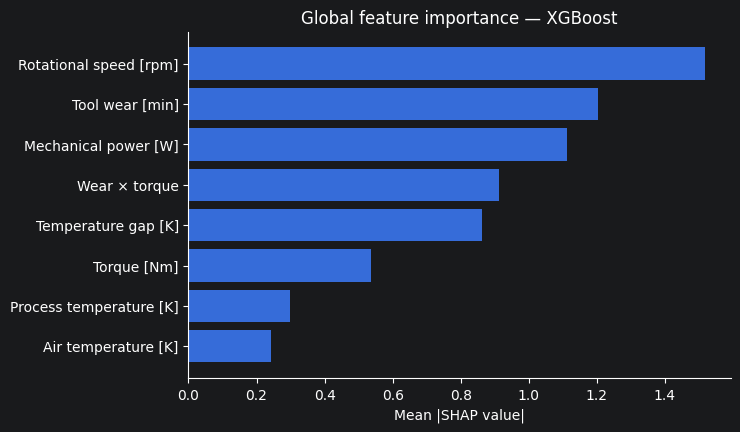

In [14]:
pre = final_model.named_steps['preprocess']
est = final_model.named_steps['model']
Xt = pre.transform(X_test_e)
feature_names = pre.get_feature_names_out()
explainer = shap.TreeExplainer(est)
sv = explainer.shap_values(Xt)
importance = pd.DataFrame({'feature':feature_names, 'mean_abs_shap':np.abs(sv).mean(axis=0)})
importance = importance.sort_values('mean_abs_shap', ascending=False)
display(importance.head(10))

top = importance.head(8).iloc[::-1]
fig, ax = plt.subplots(figsize=(7,4.5))
ax.barh(top.feature.str.replace('numeric__','', regex=False).str.replace('categorical__','', regex=False), top.mean_abs_shap)
ax.set_title('Global feature importance — XGBoost'); ax.set_xlabel('Mean |SHAP value|')
ax.spines[['top','right']].set_visible(False)
plt.show()

## 9. Error analysis — какие типы отказов модель пропускает?

Для анализа ошибок разрешено посмотреть на `TWF/HDF/PWF/OSF/RNF` **после** prediction. Эти колонки не использовались как features.

Это важный результат: часть отказов в AI4I задаётся случайно или слабо связана с доступными inputs. Поэтому 100% recall принципиально ожидать нельзя.

In [15]:
detail = df.loc[X_test.index].copy()
detail['risk_score'] = final_score
detail['prediction'] = final_pred.astype(int)
mode_rows=[]
for mode in FAILURE_MODE_COLUMNS:
    mask = detail[mode] == 1
    mode_rows.append({
        'mode':mode, 'cases':int(mask.sum()), 'detected':int(detail.loc[mask,'prediction'].sum()),
        'recall':float(detail.loc[mask,'prediction'].mean()) if mask.sum() else np.nan
    })
mode_analysis = pd.DataFrame(mode_rows)
display(mode_analysis.round(3))

false_negatives = detail[(detail[TARGET]==1) & (detail.prediction==0)]
print('False negatives:', len(false_negatives))
display(false_negatives[['Type','Air temperature [K]','Process temperature [K]','Rotational speed [rpm]',
                         'Torque [Nm]','Tool wear [min]','TWF','HDF','PWF','OSF','RNF','risk_score']].head(15))

,mode,cases,detected,recall
0,TWF,7,0,0.000
1,HDF,22,20,0.909
2,PWF,15,15,1.000
3,OSF,10,10,1.000
4,RNF,2,0,0.000


False negatives: 11


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF,risk_score
4512,H,301.6,312.9,1380,46.6,207,0,0,0,0,1,0.269805
8407,M,298.4,308.0,1415,46.7,219,1,0,0,0,0,0.104022
6583,L,299.3,307.5,1377,51.2,29,0,1,0,0,0,0.180793
8247,L,297.7,307.1,1471,41.5,207,1,0,0,0,0,0.026031
6951,H,298.3,307.9,1517,41.0,201,1,0,0,0,0,0.056368
3648,L,302.4,313.7,1530,40.7,227,1,0,0,0,0,0.536279
6532,M,298.8,306.4,1376,49.9,86,0,1,0,0,0,0.536093
1514,H,302.1,312.0,1748,30.2,231,1,0,0,0,0,0.526649
2277,L,302.1,312.1,1628,38.2,210,1,0,0,0,0,0.009951
2344,M,302.2,313.3,1537,35.2,178,0,0,0,0,1,0.021054


## 10. Responsible AI / ограничения

1. Bundled dataset — synthetic offline replica; real industrial performance не доказана.
2. `risk_score` нельзя трактовать как точную вероятность отказа: class weighting меняет calibration.
3. False negative может быть значительно дороже false positive, поэтому threshold должен определяться вместе с инженерами.
4. Модель не должна автоматически останавливать оборудование. Нужен **human-in-the-loop**.
5. На реальном предприятии нужен drift monitoring и периодическая переоценка модели.
6. TWF/RNF показывают, что некоторые события невозможно надежно предсказать по текущему набору sensor features.

## 11. Inference example

Модель сохранена в `models/xgboost_failure_risk.joblib`. FastAPI prototype использует тот же preprocessing + feature engineering, что и notebook.

In [16]:
bundle = joblib.load(ROOT / 'models' / 'xgboost_failure_risk.joblib')
example = pd.DataFrame([{
    'Type':'L', 'Air temperature [K]':300.0, 'Process temperature [K]':307.8,
    'Rotational speed [rpm]':1320, 'Torque [Nm]':58.0, 'Tool wear [min]':190
}])
example_e = add_engineered_features(example)
score = float(bundle['pipeline'].predict_proba(example_e)[:,1][0])
print({'risk_score':round(score,4), 'threshold':bundle['threshold'],
       'status':'FAILURE_RISK' if score >= bundle['threshold'] else 'NORMAL'})

{'risk_score': 0.998, 'threshold': 0.375, 'status': 'FAILURE_RISK'}


## 12. Вывод

На locked test set XGBoost значительно превосходит Dummy и Logistic baseline по failure-focused metrics. Random Forest остаётся очень конкурентным по F1, а XGBoost показывает наиболее сильный PR-AUC. Feature engineering заметно улучшает качество. Error analysis показывает не только сильные случаи модели (PWF/OSF/HDF), но и принципиальные ограничения (TWF/RNF). Именно эти ограничения должны быть честно отражены на защите.